<a href="https://www.kaggle.com/code/mh0386/digit-recognizer?scriptVersionId=294614062" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [ ]:
import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.layers import Conv2D, MaxPool2D, Flatten, Dense

In [ ]:
path = kagglehub.competition_download("digit-recognizer")

In [ ]:
train = pd.read_csv(f'{path}/train.csv')
test = pd.read_csv(f'{path}/test.csv')

In [ ]:
train

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41996,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41997,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41998,6,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
test

,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
27996,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
27997,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
27998,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
test = np.array(test)

In [ ]:
y = train['label']
X = train.drop('label', axis=1)

In [ ]:
X

,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41996,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41997,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41998,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
y

0        1
1        0
2        1
3        4
4        0
        ..
41995    0
41996    1
41997    7
41998    6
41999    9
Name: label, Length: 42000, dtype: int64

In [ ]:
test.dtype

dtype('int64')

In [ ]:
X = X / 255
test = test / 255

In [ ]:
test

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [ ]:
X = np.array(X)

In [ ]:
X = X.reshape(-1, 28, 28, 1)
test = test.reshape(-1, 28, 28, 1)

In [ ]:
X.shape

(42000, 28, 28, 1)

In [ ]:
test.dtype

dtype('float64')

In [ ]:
model = tf.keras.Sequential(
    [
        Conv2D(64, kernel_size=(3, 3), activation=tf.nn.relu),
        MaxPool2D(pool_size=(2, 2)),
        Conv2D(32, kernel_size=(3, 3), activation=tf.nn.relu),
        MaxPool2D(pool_size=(2, 2)),
        Conv2D(16, kernel_size=(3, 3), activation=tf.nn.relu),
        MaxPool2D(pool_size=(2, 2)),
        Flatten(),
        Dense(512, activation=tf.nn.relu),
        Dense(256, activation=tf.nn.relu),
        Dense(128, activation=tf.nn.relu),
        Dense(10, activation=tf.nn.softmax)
    ]
)

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
h = model.fit(
    X,
    y,
    epochs=50,
    validation_split=0.2
)

Epoch 1/50
1050/1050 [==============================] - 32s 29ms/step - loss: 0.3428 - accuracy: 0.8874 - val_loss: 0.1311 - val_accuracy: 0.9583
Epoch 2/50
1050/1050 [==============================] - 29s 28ms/step - loss: 0.1191 - accuracy: 0.9631 - val_loss: 0.0942 - val_accuracy: 0.9698
Epoch 3/50
1050/1050 [==============================] - 28s 27ms/step - loss: 0.0946 - accuracy: 0.9707 - val_loss: 0.1146 - val_accuracy: 0.9668
Epoch 4/50
1050/1050 [==============================] - 29s 27ms/step - loss: 0.0774 - accuracy: 0.9768 - val_loss: 0.0877 - val_accuracy: 0.9763
Epoch 5/50
1050/1050 [==============================] - 29s 28ms/step - loss: 0.0696 - accuracy: 0.9790 - val_loss: 0.0876 - val_accuracy: 0.9763
Epoch 6/50
1050/1050 [==============================] - 28s 27ms/step - loss: 0.0610 - accuracy: 0.9815 - val_loss: 0.0747 - val_accuracy: 0.9786
Epoch 7/50
1050/1050 [==============================] - 28s 27ms/step - loss: 0.0510 - accuracy: 0.9843 - val_loss: 0.0871 -

In [ ]:
y_pred = model.predict(test)
y_pred

875/875 [==============================] - 7s 7ms/step


array([[0.0000000e+00, 0.0000000e+00, 9.9999994e-01, ..., 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00],
       [9.9999994e-01, 7.8476742e-18, 7.4710159e-17, ..., 2.0508855e-14,
        3.2876247e-17, 1.1717119e-12],
       [7.2525615e-28, 8.6194487e-32, 6.1248032e-24, ..., 5.7979958e-20,
        1.9518578e-14, 9.9999994e-01],
       ...,
       [0.0000000e+00, 0.0000000e+00, 8.7870958e-34, ..., 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00],
       [7.5373425e-17, 1.3036469e-18, 1.6355171e-14, ..., 7.0449202e-11,
        4.3587871e-09, 9.9999994e-01],
       [0.0000000e+00, 0.0000000e+00, 9.9999994e-01, ..., 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00]], dtype=float32)

In [ ]:
y_pred = np.argmax(y_pred, axis=1)
y_pred = y_pred.astype('float64')
y_pred

array([2., 0., 9., ..., 3., 9., 2.])

In [ ]:
model.evaluate(test, y_pred)

875/875 [==============================] - 7s 8ms/step - loss: 0.0072 - accuracy: 1.0000


[0.007246661931276321, 1.0]

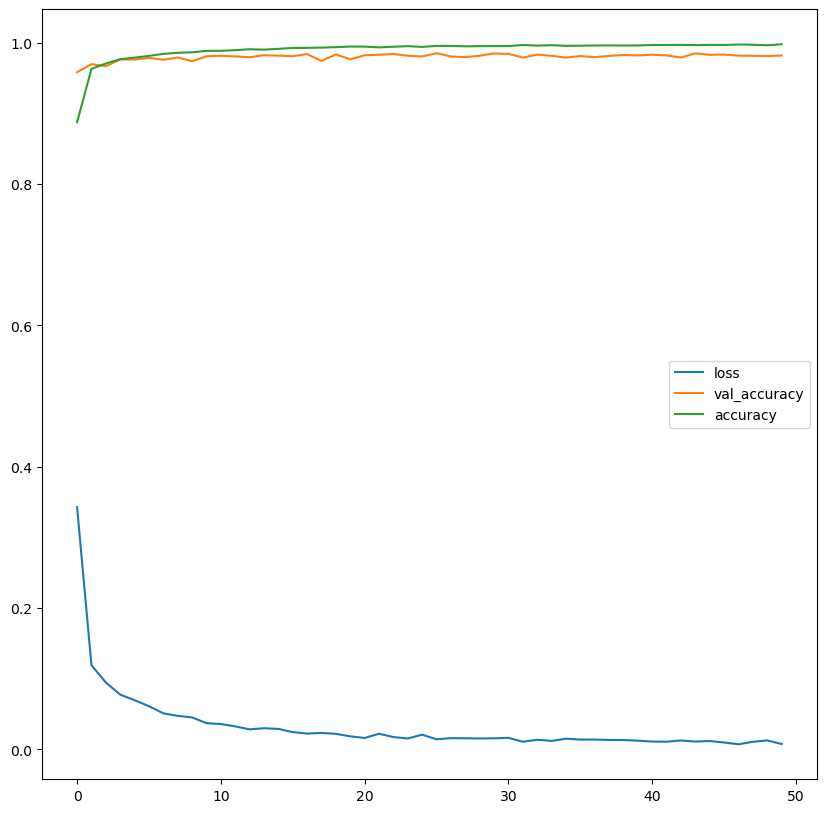

In [ ]:
plt.figure(figsize=(10, 10))
plt.plot(h.history['loss'])
plt.plot(h.history['val_accuracy'])
plt.plot(h.history['accuracy'])
plt.legend(['loss', 'val_accuracy', 'accuracy'])
plt.show()

In [ ]:
model.save('Model/model.h5')

In [ ]:
submission = pd.DataFrame(
    {
        'ImageId': range(1, len(y_pred) + 1),
        'Label': y_pred
    }
)
submission.to_csv('submission.csv', index=False)